# Comparison of Generative Data Sampling

Code is from [This Github Repo](https://github.com/Diyago/Tabular-data-generation/tree/master) to save time

basically will be running all four options and comparing outputs to show how these vary and if there is noticable difference for the quality of the data and other implications for synthetic data to improve dataset size (like if that causes bias?)


In [13]:
import kagglehub
import pandas as pd
import ipaddress
from sklearn.preprocessing import LabelEncoder

# Download latest version to compare with the two generated datasets from models
path = kagglehub.dataset_download(
    "munaalhawawreh/xiiotid-iiot-intrusion-dataset")

print("Path to dataset files:", path)
print(path)
df = pd.read_csv(path + "\\X-IIoTID dataset.csv", skipinitialspace=True)


# 1. Basic Cleaning: Strip whitespace from columns and string values
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Universal IP & Port Normalizer (Handles IPv4, IPv6, ?, -, and Ports)


def universal_to_numeric(val):
    val = str(val).strip()
    if val in ['?', '-', '', 'None']:
        return 0
    try:
        # If it looks like an IP, convert to int
        if '.' in val or ':' in val:
            return int(ipaddress.ip_address(val))
        # Otherwise, treat as a standard number
        return int(float(val))
    except:
        return 0


for col in ['Scr_IP', 'Des_IP', 'Scr_port', 'Des_port']:
    df[col] = df[col].apply(universal_to_numeric)

# 3. Timestamp Fix (Convert Unix to Numeric safely)
df['Timestamp'] = pd.to_numeric(
    df['Timestamp'], errors='coerce').fillna(0).astype(int)
df['Time'] = pd.to_datetime(df['Timestamp'], unit='s')
df.drop(columns=['Timestamp'], inplace=True)
# 4. Boolean/Flag Mapping (TRUE/FALSE strings or actual Bools -> 0/1)
bool_cols = [
    'is_syn_only', 'Is_SYN_ACK', 'is_pure_ack', 'is_with_payload',
    'FIN or RST', 'Bad_checksum', 'is_SYN_with_RST', 'anomaly_alert'
]
for col in bool_cols:
    if col in df.columns:
        # Map strings if they exist, otherwise force to int
        if df[col].dtype == 'object':
            df[col] = df[col].str.upper().map(
                {'TRUE': 1, 'FALSE': 0, '-': 0, '?': 0})
        df[col] = df[col].fillna(0).astype(int)

# 5. Mass Numeric Conversion for Metrics (Duration, Bytes, CPU stats, etc.)
# We replace '?' and '-' with 0 first
df.replace(['?', '-'], 0, inplace=True)
cat_cols = ['Protocol', 'Service', 'class1', 'class2', 'class3']
encoders = {}
# 6. Categorical Cleanup
for col in ['Protocol', 'Service']:
    df[col] = df[col].replace(0, 'unknown').astype(str)
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        # Ensure everything is a string before encoding to avoid mixed-type errors
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

# 3. Final safety check: ensure NO strings remain in the numeric features
# (This prevents the 'udp' error once and for all)
for col in df.columns:
    if df[col].dtype == 'object':
        # If any stray strings exist, force them to numeric or drop
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
# Identify all columns that should be numeric (excluding categorical labels)

numeric_cols = [c for c in df.columns if c not in cat_cols + ['Date']]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 7. Final Drop
df.drop(columns=['Date'], inplace=True)

df.info()

Path to dataset files: C:\Users\antho\.cache\kagglehub\datasets\munaalhawawreh\xiiotid-iiot-intrusion-dataset\versions\1
C:\Users\antho\.cache\kagglehub\datasets\munaalhawawreh\xiiotid-iiot-intrusion-dataset\versions\1
<class 'pandas.DataFrame'>
RangeIndex: 820834 entries, 0 to 820833
Data columns (total 67 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Scr_IP                       820834 non-null  float64
 1   Scr_port                     820834 non-null  int64  
 2   Des_IP                       820834 non-null  float64
 3   Des_port                     820834 non-null  int64  
 4   Protocol                     820834 non-null  int64  
 5   Service                      820834 non-null  int64  
 6   Duration                     820834 non-null  float64
 7   Scr_bytes                    820834 non-null  int64  
 8   Des_bytes                    820834 non-null  int64  
 9   Conn_state                 

In [14]:
df.head()

,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,Des_bytes,Conn_state,missed_bytes,is_syn_only,Is_SYN_ACK,is_pure_ack,is_with_payload,FIN or RST,Bad_checksum,is_SYN_with_RST,Scr_pkts,Scr_ip_bytes,Des_pkts,Des_ip_bytes,anomaly_alert,total_bytes,total_packet,paket_rate,byte_rate,Scr_packts_ratio,Des_pkts_ratio,Scr_bytes_ratio,Des_bytes_ratio,Avg_user_time,Std_user_time,Avg_nice_time,Std_nice_time,Avg_system_time,Std_system_time,Avg_iowait_time,Std_iowait_time,Avg_ideal_time,Std_ideal_time,Avg_tps,Std_tps,Avg_rtps,Std_rtps,Avg_wtps,Std_wtps,Avg_ldavg_1,Std_ldavg_1,Avg_kbmemused,Std_kbmemused,Avg_num_Proc/s,Std_num_proc/s,Avg_num_cswch/s,std_num_cswch/s,OSSEC_alert,OSSEC_alert_level,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3,Time
0,3.232236e+09,49278,3.232236e+09,80,1,4,0.673690,13437,34924,1,0.0,1,1,1,1,1,0,0,105,18905.0,105,40392,1,107658,210,311.716071,1.598035e+05,0.500000,0.500000,0.300414,0.699586,9.207,5.555842,10.994,1.356305,4.864,1.873004,0.311,0.224653,74.624,8.245611,12.297,10.385850,8.0,10.507140,4.297,2.723579,2.146,0.102781,915852.8,2507.975630,5.1,3.238827,2806.2,158.749362,1,5,0,0,0,0,0,0,14,6,0,1578540956
1,1.677724e+08,39769,2.213283e+09,53,2,2,0.000083,78,0,1,0.0,0,0,0,1,0,0,0,2,134.0,0,0,0,212,2,24096.385540,2.554217e+06,1.000000,0.000000,1.000000,0.000000,12.326,6.674248,2.895,1.604302,3.778,2.099742,2.741,5.327471,78.263,8.869399,6.600,5.713143,0.0,0.000000,6.600,5.713143,0.612,0.037630,910498.4,4044.112046,1.0,0.894427,1561.6,247.080230,0,0,0,0,0,0,0,0,11,4,1,1578871873
2,2.887254e+09,59050,2.887254e+09,53,2,2,0.000132,38,38,1,0.0,0,0,0,1,0,0,0,1,66.0,1,66,0,208,2,15151.515150,1.575758e+06,0.500000,0.500000,0.500000,0.500000,6.931,6.416007,0.706,0.408906,1.693,0.771635,2.423,3.829810,88.245,7.112108,37.400,40.190049,30.1,39.798116,7.300,3.100000,0.550,0.020000,921020.4,2139.652645,1.0,0.000000,1603.3,294.139100,0,0,0,0,0,0,0,0,11,4,1,1578522486
3,3.232236e+09,37966,3.232236e+09,1880,1,16,9.378481,1121,484,1,0.0,1,1,1,1,1,0,0,8,1545.0,6,804,0,3954,14,1.492779,4.216035e+02,0.571429,0.428571,0.674254,0.325746,10.244,7.932040,1.965,1.514168,3.941,1.709055,0.509,0.425522,83.339,10.206087,29.000,26.574424,23.3,26.126806,5.700,6.229767,0.708,0.026000,915874.8,977.885147,7.2,5.325411,1685.3,467.873712,0,0,1,1,1,1,1,1,11,4,1,1582757640
4,2.887254e+09,38233,2.887254e+09,53,2,2,0.000074,0,0,1,0.0,0,0,0,1,0,0,0,0,0.0,0,0,0,0,0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,5.181,5.980459,2.365,1.284463,2.415,1.401151,1.803,4.478256,88.239,8.090018,9.800,1.326650,0.1,0.300000,9.700,1.268858,0.536,0.030067,918213.2,2342.938360,0.6,0.489898,1456.5,346.884779,0,0,0,0,0,0,0,0,11,4,1,1576452612


In [15]:
df.describe()

,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,Des_bytes,Conn_state,missed_bytes,is_syn_only,Is_SYN_ACK,is_pure_ack,is_with_payload,FIN or RST,Bad_checksum,is_SYN_with_RST,Scr_pkts,Scr_ip_bytes,Des_pkts,Des_ip_bytes,anomaly_alert,total_bytes,total_packet,paket_rate,byte_rate,Scr_packts_ratio,Des_pkts_ratio,Scr_bytes_ratio,Des_bytes_ratio,Avg_user_time,Std_user_time,Avg_nice_time,Std_nice_time,Avg_system_time,Std_system_time,Avg_iowait_time,Std_iowait_time,Avg_ideal_time,Std_ideal_time,Avg_tps,Std_tps,Avg_rtps,Std_rtps,Avg_wtps,Std_wtps,Avg_ldavg_1,Std_ldavg_1,Avg_kbmemused,Std_kbmemused,Avg_num_Proc/s,Std_num_proc/s,Avg_num_cswch/s,std_num_cswch/s,OSSEC_alert,OSSEC_alert_level,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3,Time
count,8.208340e+05,820834.000000,8.208340e+05,820834.000000,820834.000000,820834.000000,820834.000000,8.208340e+05,8.208340e+05,820834.000000,8.208340e+05,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.0,820834.0,820834.000000,8.208340e+05,820834.000000,8.208340e+05,820834.000000,8.208340e+05,820834.000000,8.208340e+05,8.208340e+05,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,820834.000000,8.208340e+05
mean,2.439797e+35,35635.117894,2.444278e+35,1746.322722,1.479027,4.524089,8.834584,1.500625e+03,4.104829e+04,0.851623,2.768320e+01,0.512220,0.393538,0.393853,0.867186,0.506172,0.0,0.0,19.610256,2.507672e+03,27.848024,4.336439e+04,0.076386,8.837400e+04,47.458280,2.179966e+04,2.320767e+06,0.524060,0.289858,0.416419,0.310844,10.105284,5.852589,2.703972,1.546433,4.577583,1.633314,2.155804,3.575537,80.399094,9.474753,15.827812,13.074988,7.118150,9.591289,8.709679,5.901541,0.994898,0.058072,912885.769870,2488.058550,2.690997,2.955966,3941.383484,622.619434,0.051186,0.267717,0.087305,0.082730,0.072650,0.082620,0.355309,0.082456,10.058964,4.696147,0.513401,1.229242e+09
std,9.081635e+36,21886.415529,9.098319e+36,4383.524522,0.506535,4.651246,113.660695,7.446342e+03,2.806029e+05,0.355474,3.647097e+03,0.499851,0.488535,0.488603,0.339373,0.499962,0.0,0.0,270.671744,1.930668e+04,262.677235,2.911188e+05,0.265614,5.796652e+05,527.248291,8.198869e+04,9.756382e+06,0.322195,0.245415,0.358411,0.315697,8.963497,2.401832,2.002247,0.842467,4.278904,0.879767,3.649368,5.709182,13.706643,4.471797,15.711444,14.693723,15.102222,15.410537,4.261830,5.130922,0.646792,0.081727,35943.622171,2367.759303,580.091032,820.360451,5265.892963,863.024959,0.220377,1.178027,0.282282,0.275475,0.259562,0.275307,0.478607,0.275059,3.622164,1.425801,0.499821,6.566496e+08
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.198966,0.000000,-0.498306,0.000000,0.000000,-45.500000,-19.152128,0.000000,0.000000,-46.300000,-42.037441,0.000000,-0.163691,0.000000,0.000000,-11.900000,-24.694497,-861.400000,-1918.070330,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2.887254e+09,13307.000000,2.887254e+09,53.000000,1.000000,2.000000,0.000094,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,1.000000,6.000000e+01,0.000000,0.000000e+00,0.000

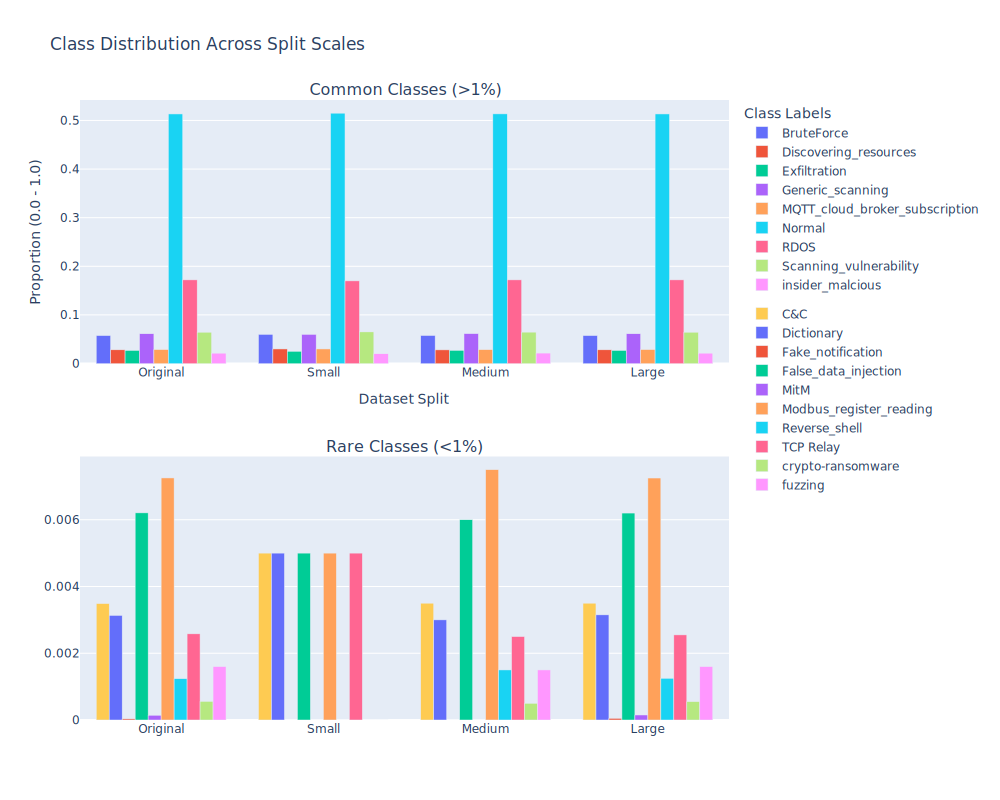

--- Detailed Distribution Table (class1) ---
                                Original (count)  Original (%)  Small Test Set (count)  Small Test Set (%)  Medium Test Set (count)  Medium Test Set (%)  Large Test Set (count)  Large Test Set (%)
BruteForce                                 47241       5.75524                    12.0                 6.0                    115.0                 5.75                    1151               5.755
C&C                                         2863       0.34879                     1.0                 0.5                      7.0                 0.35                      70               0.350
Dictionary                                  2572       0.31334                     1.0                 0.5                      6.0                 0.30                      63               0.315
Discovering_resources                      23148       2.82006                     6.0                 3.0                     56.0                 2.80               

In [16]:
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "svg"
target_cols = ['class1', 'class2', 'class3']

X = df.drop(columns=target_cols)
y = df[['class1']]  # Focus on class1 for now

# Create the 1,000 row set
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X, y, train_size=800, test_size=200, stratify=y, random_state=42
)

X_train_med, X_test_med, y_train_med, y_test_med = train_test_split(
    X, y, train_size=8000, test_size=2000, stratify=y, random_state=42
)

# Create the 10,000 row set
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    X, y, train_size=80000, test_size=20000, stratify=y, random_state=42
)

labels = encoders['class1'].classes_

dataset_names = ['Original', 'Small', 'Medium', 'Large']


def get_dist(series, labels):
    dist = series.value_counts(normalize=True).reindex(
        range(len(labels)), fill_value=0)
    dist.index = labels
    return dist


original_dist = get_dist(df['class1'], labels)
small_test_dist = get_dist(y_test_small['class1'], labels)
med_test_dist = get_dist(y_test_med['class1'], labels)
large_test_dist = get_dist(y_test_large['class1'], labels)

# Group distributions for iteration
all_dists = [original_dist, small_test_dist, med_test_dist, large_test_dist]

threshold = 0.01
common_classes = original_dist[original_dist > threshold].index
rare_classes = original_dist[original_dist <= threshold].index

fig = make_subplots(rows=2, cols=1,
                    subplot_titles=("Common Classes (>1%)",
                                    "Rare Classes (<1%)"),
                    vertical_spacing=0.15)

# Add Common Classes to Legend
for cls in common_classes:
    y_vals = [d[cls] for d in all_dists]
    fig.add_trace(go.Bar(
        x=dataset_names,
        y=y_vals,
        name=str(cls),
        legendgroup="common"  # Optional: groups them in the legend
    ), row=1, col=1)

# Add Rare Classes to Legend
for cls in rare_classes:
    y_vals = [d[cls] for d in all_dists]
    fig.add_trace(go.Bar(
        x=dataset_names,
        y=y_vals,
        name=str(cls),
        legendgroup="rare"
    ), row=2, col=1)

# 5. Update Layout
fig.update_layout(
    width=1000,
    height=800,
    barmode='group',  # Set to 'stack' if you want to see total composition
    title="Class Distribution Across Split Scales",
    xaxis_title="Dataset Split",
    yaxis_title="Proportion (0.0 - 1.0)",
    legend_title="Class Labels",
    showlegend=True
)

fig.write_image("Data_Distribution_Legend.svg")
fig.show()

# --- Table Printing Logic ---
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)  # Ensure the width is large enough

orig_counts = df['class1'].value_counts()
orig_pcts = df['class1'].value_counts(normalize=True) * 100

# 2. Calculate counts and percentages for the Test Set
small_test_counts = y_test_small['class1'].value_counts()
small_test_pcts = y_test_small['class1'].value_counts(normalize=True) * 100
med_test_dist = y_test_med['class1'].value_counts()
med_test_pcts = y_test_med['class1'].value_counts(normalize=True) * 100
large_test_counts = y_test_large['class1'].value_counts()
large_test_pcts = y_test_large['class1'].value_counts(normalize=True) * 100

# 3. Combine into a single detailed DataFrame
comparison_table = pd.DataFrame({
    'Original (count)': orig_counts,
    'Original (%)': orig_pcts,
    'Small Test Set (count)': small_test_counts,
    'Small Test Set (%)': small_test_pcts,
    'Medium Test Set (count)': med_test_dist,
    'Medium Test Set (%)': med_test_pcts,
    'Large Test Set (count)': large_test_counts,
    'Large Test Set (%)': large_test_pcts
})


labels = encoders['class1'].classes_
comparison_table.index = [labels[i] for i in comparison_table.index]

# 5. Clean up the display
print("--- Detailed Distribution Table (class1) ---")
print(comparison_table.round(5))

In [ ]:
from tabgan.sampler import GANGenerator, ForestDiffusionGenerator, LLMGenerator

categorical_features = ['Protocol', 'Service']

small_GAN_train, small_GAN_target = GANGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 50, "patience": 15, "epochs": 300, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_small, target=y_train_small, test_df=X_test_small)
small_Diff_train, small_Diff_target = ForestDiffusionGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 130, "patience": 10, "epochs": 100, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_small, target=y_train_small, test_df=X_test_small)
small_LLM_train, small_LLM_target = LLMGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 30, "patience": 15, "epochs": 100, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_small, target=y_train_small, test_df=X_test_small)

Training CTGAN, epochs::   7%|▋         | 20/300 [00:12<02:49,  1.65it/s]


KeyboardInterrupt: 

In [ ]:

small_GAN_train, small_GAN_target
small_Diff_train, small_Diff_target
small_LLM_train, small_LLM_target

small_GAN_dist = get_dist(small_GAN_target, labels)
small_Diff_dist = get_dist(small_GAN_target, labels)
small_LLM_dist = get_dist(small_GAN_target, labels)

# Group distributions for iteration
all_dists = [original_dist, small_GAN_dist, small_Diff_dist, small_LLM_dist]
dataset_names = ['Original', 'Small GAN', 'Small Diffusion', 'Small LLM']


fig = make_subplots(rows=2, cols=1,
                    subplot_titles=("Common Classes (>1%)",
                                    "Rare Classes (<1%)"),
                    vertical_spacing=0.15)

# Add Common Classes to Legend
for cls in common_classes:
    y_vals = [d[cls] for d in all_dists]
    fig.add_trace(go.Bar(
        x=dataset_names,
        y=y_vals,
        name=str(cls),
        legendgroup="common"  # Optional: groups them in the legend
    ), row=1, col=1)

# Add Rare Classes to Legend
for cls in rare_classes:
    y_vals = [d[cls] for d in all_dists]
    fig.add_trace(go.Bar(
        x=dataset_names,
        y=y_vals,
        name=str(cls),
        legendgroup="rare"
    ), row=2, col=1)

# 5. Update Layout
fig.update_layout(
    width=1000,
    height=800,
    barmode='group',  # Set to 'stack' if you want to see total composition
    title="Class Distribution Across Split Scales - Small Dataset",
    xaxis_title="Dataset Split",
    yaxis_title="Proportion (0.0 - 1.0)",
    legend_title="Class Labels",
    showlegend=True
)

fig.write_image("Data_Distribution_Legend.svg")
fig.show()

small_GAN_counts = pd.Series(small_GAN_target).value_counts()
small_GAN_pcts = pd.Series(small_GAN_target).value_counts(normalize=True) * 100
small_Diff_counts = pd.Series(small_Diff_target).value_counts()
small_Diff_pcts = pd.Series(
    small_Diff_target).value_counts(normalize=True) * 100
small_LLM_counts = pd.Series(small_LLM_target).value_counts()
small_LLM_pcts = pd.Series(small_LLM_target).value_counts(normalize=True) * 100


# 3. Combine into a single detailed DataFrame
comparison_table = pd.DataFrame({
    'Original (count)': orig_counts,
    'Original (%)': orig_pcts,
    'Small GAN (count)': small_GAN_counts,
    'Small GAN (%)': small_GAN_pcts,
    'Small Diffusion (count)': small_Diff_counts,
    'Small Diffusion (%)': small_Diff_pcts,
    'Small LLM (count)': small_LLM_counts,
    'Small LLM (%)': small_LLM_pcts
})


labels = encoders['class1'].classes_
comparison_table.index = [labels[i] for i in comparison_table.index]

# 5. Clean up the display
print("--- Detailed Distribution Table (class1) ---")
print(comparison_table.round(5))

In [ ]:
med_GAN_train, med_GAN_target = GANGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 260, "patience": 25, "epochs": 300, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_med, target=y_train_med, test_df=X_test_med)
med_Diff_train, med_Diff_target = ForestDiffusionGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 260, "patience": 15, "epochs": 150, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_med, target=y_train_med, test_df=X_test_med)
med_LLM_train, med_LLM_target = LLMGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 60, "patience": 10, "epochs": 50, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_med, target=y_train_med, test_df=X_test_med)

In [ ]:
large_GAN_train, large_GAN_target = GANGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 500, "patience": 25, "epochs": 300, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_large, target=y_train_large, test_df=X_test_large)
large_Diff_train, large_Diff_target = ForestDiffusionGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 500, "patience": 10, "epochs": 100, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_large, target=y_train_large, test_df=X_test_large)
large_LLM_train, large_LLM_target = LLMGenerator(gen_params={
    'cat_cols': categorical_features, "deep_copy": True, "only_generated_data": True,
    "batch_size": 130, "patience": 5, "epochs": 30, "gen_x_times": 2}) \
    .generate_data_pipe(train_df=X_train_large, target=y_train_large, test_df=X_test_large)